In [59]:
import requests
import pandas as pd

In [60]:
# 1. Fetch data from OpenAlex API
url = "https://api.openalex.org/works?search.title_and_abstract=misinformation+corrective+strategy&sort=relevance_score%3Adesc"
response = requests.get(url)
data = response.json()

# Helper function to reconstruct the abstract from the inverted index
def reconstruct_abstract(inverted_index):
    if not inverted_index:
        return "N/A"
    try:
        # Find the max position to determine the text length
        max_pos = max([max(pos_list) for pos_list in inverted_index.values()])
        words = [None] * (max_pos + 1)
        for word, pos_list in inverted_index.items():
            for pos in pos_list:
                words[pos] = word
        return " ".join([w for w in words if w is not None])
    except:
        return "N/A"

# 2. Extract and Flatten the Data
rows = []
for work in data.get('results', []):
    # Get all author names
    authorships = work.get('authorships', [])
    author_list = [a.get('author', {}).get('display_name') for a in authorships]
    
    # Extract IDS 
    ids = work.get('ids', {})
    doi_link = ids.get('doi')

    # Extract unique institutions and countries
    inst_names = set()
    countries = set()
    for auth in authorships:
        for inst in auth.get('institutions', []):
            inst_names.add(inst.get('display_name'))
            if inst.get('country_code'):
                countries.add(inst.get('country_code'))
    
    # Get broad disciplinary fields (Level 0 concepts)
    disciplines = [c['display_name'] for c in work.get('concepts', []) if c.get('level') == 0]

    rows.append({
        'ID': work.get('id'),
        'DOI': doi_link,
        'Title': work.get('title'),
        'Year': work.get('publication_year'),
        'Citations': work.get('cited_by_count'),
        'Impact_Score_FWCI': work.get('fwci'),
        'Authors': "; ".join(author_list),
        'Institutions': "; ".join(list(inst_names)),
        'Countries': "; ".join(list(countries)),
        'Broad_Disciplines': "; ".join(disciplines),
        'Abstract': reconstruct_abstract(work.get('abstract_inverted_index'))
    })

# 3. Create DataFrame and Save
df = pd.DataFrame(rows)
df.to_csv('misinformation_dataset.csv', index=False)
print("Transformation Complete! Here is the top of your table:")
print(df[['Title', 'Citations', 'Broad_Disciplines']].head())

Transformation Complete! Here is the top of your table:
                                               Title  Citations  \
0  The effectiveness of misinformation corrective...          3   
1  Crisis Misinformation and Corrective Strategie...          5   
2  Misinformation lingers in memory: Failure of t...        269   
3  Addressing COVID-19 Misinformation on Social M...        152   
4  The Effects of Corrective Communication and Em...         73   

                                   Broad_Disciplines  
0             Economics; Business; Political science  
1  Psychology; Business; Political science; Compu...  
2  Medicine; Psychology; Computer science; Politi...  
3  Computer science; Psychology; Medicine; Philos...  
4  Business; Psychology; Political science; Compu...  


In [61]:
df.head()

,ID,DOI,Title,Year,Citations,Impact_Score_FWCI,Authors,Institutions,Countries,Broad_Disciplines,Abstract
0,https://openalex.org/W4404079617,https://doi.org/10.1002/aepp.13487,The effectiveness of misinformation corrective...,2024,3,1.0343,Lin Lin; David L. Ortega; Jiayu Sun,Michigan State University,US,Economics; Business; Political science,Abstract This study investigates the effect of...
1,https://openalex.org/W4206450379,https://doi.org/10.4324/9781003043409-15,Crisis Misinformation and Corrective Strategie...,2022,5,4.6332,Toni G.L.A. van der Meer; Yan Jin,,,Psychology; Business; Political science; Compu...,The social-mediated crisis communication domai...
2,https://openalex.org/W2736876412,https://doi.org/10.1371/journal.pone.0181640,Misinformation lingers in memory: Failure of t...,2017,269,75.4686,Sara Pluviano; Caroline Watt; Sergio Della Sala,Università degli Studi Suor Orsola Benincasa; ...,GB; IT,Medicine; Psychology; Computer science; Politi...,People's inability to update their memories in...
3,https://openalex.org/W3118516682,https://doi.org/10.3201/eid2702.203139,Addressing COVID-19 Misinformation on Social M...,2021,152,42.1503,Emily K. Vraga; Leticia Bode,University of Minnesota; Georgetown University,US,Computer science; Psychology; Medicine; Philos...,Efforts to address misinformation on social me...
4,https://openalex.org/W3023832873,https://doi.org/10.1016/j.pubrev.2020.101910,The Effects of Corrective Communication and Em...,2020,73,11.6791,Yan Jin; Toni G.L.A. van der Meer; Yen-I Lee; ...,University of Georgia; University of Amsterdam...,US; NL,Business; Psychology; Political science; Compu...,N/A


In [62]:
df.to_csv('Dataset_raw_finalproject_is577')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 25 non-null     object 
 1   DOI                25 non-null     object 
 2   Title              25 non-null     object 
 3   Year               25 non-null     int64  
 4   Citations          25 non-null     int64  
 5   Impact_Score_FWCI  25 non-null     float64
 6   Authors            25 non-null     object 
 7   Institutions       25 non-null     object 
 8   Countries          25 non-null     object 
 9   Broad_Disciplines  25 non-null     object 
 10  Abstract           25 non-null     object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.3+ KB


In [64]:
#Check for duplicates based on DOI

initial_count = len(df)
df = df.drop_duplicates(subset="DOI")
print(f"\nRemoved {initial_count - len(df)} duplicate papers")


Removed 0 duplicate papers


In [65]:
# Function to clean strings : lowercase, remove extra spaces, handle 'N/A'ArithmeticError

def clean_string(text):
    if pd.isna(text) or text == "N/A":
        return ""
    return str(text).lower().strip()


# Apply to grouping columns

df['Authors'] = df['Authors'].apply(clean_string)
df['Institutions'] = df['Institutions'].apply(clean_string)
df['Broad_Disciplines'] = df['Broad_Disciplines'].apply(clean_string)
df['Countries'] = df['Countries'].apply(clean_string)

In [66]:
# Convert Year to numeric, forcing errors to 'NaN' then filling them
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(0).astype(int)

# Filter out anything with year 0 if necessary
df = df[df['Year'] > 0]

# Analysis Process

3. Descriptive Analytics (Answering the "Who" and "Where")
- Expert Ranking: Value counts of the "Exploded" author column.

- Geospatial Prep: Group by Country to see which nations lead the research.

- Trend Analysis: Plot a line chart of Citations or Paper Count over Year to see if "Corrective Strategies" are a growing trend.

4. Text Mining (Answering the "How" and "What")
- Keyword Frequency: Use a Counter or WordCloud on the Abstract column to identify specific solutions (e.g., "nudging," "fact-checking").

- Stopword Removal: Filter out common words (the, and, of) to find the domain-specific technical terms.

5. Visualization Strategy
- Network Graph: (Advanced) If you want to see how experts collaborate, look into the NetworkX library to map Author-to-Author connections.

- Disciplinary Split: Create a Treemap of the Broad_Disciplines to show if the field is dominated by Social Science or Computer Science.



6. Next Analytical Steps (The "Marketing to Analytics" Transition)
To turn these numbers into a professional report or visualization, I recommend these three moves:

-  N-Gram Analysis (Bigrams)
Single words like "social" are vague. If you run a Bigram (two-word) analysis, you'll likely find "social media," "fake news," and "corrective messages," which are much more descriptive for your dataset.


*COMPARISION FLOW*

-  "Solution" Filtering
Create a subset of your data where the abstract contains "debunking," "pre-bunking," or "fact-check." Compare the Citations of these papers.

    => Question: Are "pre-bunking" papers cited more than "debunking" papers?

-  Disciplinary Cross-Tab
Compare keywords by Broad_Disciplines.

    => Do Computer Science papers use words like "algorithm" and "detection," while Psychology papers use "anger" and "cognition"?

    => Which of these "emotional" or "technical" keywords surprises you the most in this top 30 list?

*TREND INDENTIFICATION*

- Volume Acceleration: Does the number of papers spike during specific global events (e.g., 2020 pandemic, 2024 elections)?

- Shift in Methodology: Does the terminology shift from manual (e.g., fact-checking) to automated (e.g., algorithmic detection, machine learning) over time?

- Reactive vs. Proactive: Look for the rise of "Pre-bunking" or "Inoculation" in recent years compared to older "Debunking" research.

- Platform Evolution: Track if mentions of specific platforms change (e.g., the decline of "Facebook" mentions vs. the rise of "TikTok" or "WhatsApp").

- Disciplinary Dominance: Does the "Broad Discipline" tag shift from Social Science (behavioral) to Computer Science (engineering) as the years progress?

- Citation Velocity: Identify which "Keywords" or "Phrases" are present in the top 5% most-cited papers vs. the least-cited ones.


# Exploratory Data Analysis

In [67]:
# 1. Split the string into a list
df['Author_List'] = df['Authors'].str.split(';')

# 2. Explode the list into individual rows
# This will multiply the rows in your dataframe—one row per author per paper.
authors_df = df.explode('Author_List')

# 3. Clean up the new column
authors_df['Author_List'] = authors_df['Author_List'].str.strip()

# Now you can answer: "Who are the experts?"
top_experts = authors_df['Author_List'].value_counts().head(10)
print("\nTop 10 Experts by Paper Count:")
print(top_experts)


Top 10 Experts by Paper Count:
Author_List
yan jin                     3
yen-i lee                   2
arunima krishna             2
toni g.l.a. van der meer    2
michelle a. amazeen         2
xuerong lu                  2
xiuzhen zhang               1
danielle deavours           1
brian britt                 1
shaheen kanthawala          1
Name: count, dtype: int64


In [68]:
# Calculate total citations per author to find 'Impactful Experts'
expert_impact = authors_df.groupby('Author_List')['Citations'].sum().sort_values(ascending=False).head(10)

# Calculate which countries are most 'Concerned' with this topic
country_counts = df['Countries'].str.split(';').explode().str.strip().value_counts()

print("Top 10 High-Impact Experts (by Citations):")
print(expert_impact)

print("\nTop Research Hubs (by Country):")
print(country_counts.head(5))

Top 10 High-Impact Experts (by Citations):
Author_List
sara pluviano        269
sergio della sala    269
caroline watt        269
aage indahl          212
torill h. tveito     212
rob smeets           212
serge poiraudeau     212
james rainville      212
tom bendix           212
leticia bode         152
Name: Citations, dtype: int64

Top Research Hubs (by Country):
Countries
us    19
gb     5
au     3
nl     2
       1
Name: count, dtype: int64


In [69]:
# Explode disciplines to count them individually
discipline_counts = df['Broad_Disciplines'].str.split(';').explode().str.strip().value_counts()

# Calculate percentages for a clearer picture
discipline_pct = (discipline_counts / discipline_counts.sum()) * 100

print("\nDisciplinary Distribution (%):")
print(discipline_pct.head(5))


Disciplinary Distribution (%):
Broad_Disciplines
psychology           22.619048
computer science     22.619048
political science    16.666667
business              7.142857
medicine              5.952381
Name: count, dtype: float64


In [70]:
# # Trend Plotting 

# import matplotlib.pyplot as plt

# # Group papers by Year 
# papers_per_year = df.groupby('Year').size().sort_index()

# # Group total citation impact by Year
# citations_per_year = df.groupby('Year')['Citations'].sum().sort_index()

# # Plotting

# fig, ax1 = plt.subplots(figsize = (10,6))


# # Primary Axis: Number of Papers (Bar or Line)
# ax1.set_xlabel('Year')
# ax1.set_ylabel('Number of Papers', color='tab:blue')
# ax1.plot(papers_per_year.index, papers_per_year.values, marker='o', color='tab:blue', linewidth=2, label='Papers published')
# ax1.tick_params(axis='y', labelcolor='tab:blue')

# # Secondary Axis: Citation Count (Total Impact)
# ax2 = ax1.twinx() 
# ax2.set_ylabel('Total Citations', color='tab:red')
# ax2.plot(citations_per_year.index, citations_per_year.values, marker='s', color='tab:red', linestyle='--', linewidth=2, label='Total Citations')
# ax2.tick_params(axis='y', labelcolor='tab:red')

# plt.title('Trend of Misinformation Corrective Strategy Research (2018-2024)')
# plt.grid(True, alpha=0.3)
# fig.tight_layout()


# TEXT MINING 

In [71]:
#Remove stopwords and punctuation

from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if you haven't already
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Add "Domain Noise" - words that appear often in research but aren't solutions
domain_noise = {'study', 'research', 'findings', 'results', 'participants', 'suggest', 'using', 'found', 'effect', 'effects', 'paper', 'analysis'}
stop_words.update(domain_noise)

def get_clean_keywords(text_series, top_n=30):
    # 1. Combine all abstracts and lowercase
    all_text = " ".join(text_series.astype(str)).lower()
    
    # 2. Clean punctuation and keep only alphabetic words
    words = re.findall(r'\b[a-z]{3,}\b', all_text)
    
    # 3. Filter stopwords and noise
    meaningful_words = [w for w in words if w not in stop_words]
    
    return Counter(meaningful_words).most_common(top_n)

# Execute on your cleaned dataframe
solution_keywords = get_clean_keywords(df['Abstract'])

print("--- Top Domain-Specific Keywords ---")
for word, count in solution_keywords:
    print(f"{word:15} | {count}")

--- Top Domain-Specific Keywords ---
misinformation  | 77
corrective      | 42
media           | 21
messages        | 21
strategies      | 20
news            | 20
social          | 19
crisis          | 18
fake            | 18
information     | 16
correction      | 16
knowledge       | 15
health          | 15
communication   | 14
intention       | 13
debunking       | 12
current         | 11
industry        | 10
effective       | 9
tweets          | 9
deception       | 9
fact            | 8
science         | 8
literacy        | 8
tobacco         | 8
smoking         | 8
mitigation      | 7
spread          | 7
two             | 7
however         | 7


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nganhoang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [72]:
pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


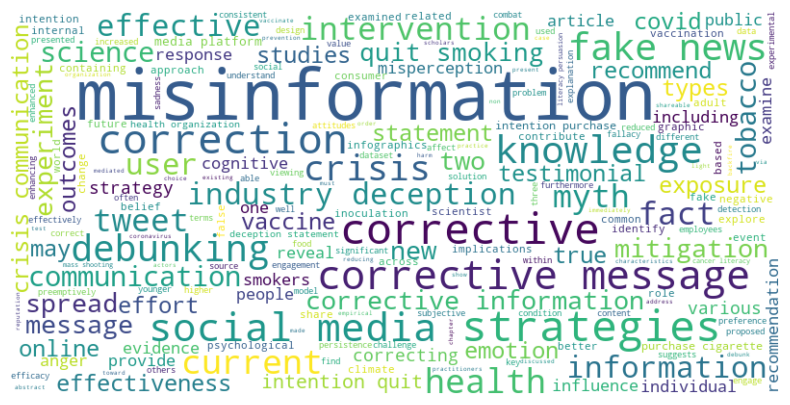

In [73]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate the cloud from the meaningful_words list
text_for_cloud = " ".join([w for w in re.findall(r'\b[a-z]{3,}\b', " ".join(df['Abstract'].astype(str)).lower()) if w not in stop_words])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_for_cloud)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [74]:
# Quick Bigram extraction using basic Python
def get_bigrams(text_series):
    bigrams = []
    for abstract in text_series.astype(str):
        # Basic cleaning
        words = re.findall(r'\b[a-z]{3,}\b', abstract.lower())
        words = [w for w in words if w not in stop_words]
        
        # Zip words with themselves shifted by 1 to get pairs
        for pair in zip(words, words[1:]):
            bigrams.append(" ".join(pair))
    return Counter(bigrams).most_common(20)

top_bigrams = get_bigrams(df['Abstract'])
print("\nTop 20 Research Phrases (Bigrams):")
for phrase, count in top_bigrams:
    print(f"{phrase:25} | {count}")


Top 20 Research Phrases (Bigrams):
social media              | 16
corrective messages       | 16
fake news                 | 14
industry deception        | 9
crisis misinformation     | 7
corrective information    | 7
quit smoking              | 7
crisis communication      | 6
intention quit            | 6
intention purchase        | 5
current corrective        | 5
health misinformation     | 5
media platforms           | 4
true news                 | 4
purchase cigarettes       | 4
deception statement       | 4
mitigation strategies     | 3
correcting misinformation | 3
corrective communication  | 3
misinformation corrective | 3


# TREND ANALYSIS

In [75]:
#VOLUME ACCELERATION

#Calculate Year-over-year growth

#Count papers per year
yearly_counts = df.groupby('Year').size().reset_index(name='Paper_Count')
yearly_counts = yearly_counts.sort_values('Year')

#Calculate Percentage Change (Velocity)
yearly_counts['YoY_Growth_Rate'] = yearly_counts['Paper_Count'].pct_change()*100

#Calculate Acceleration (the change in growth rate)
yearly_counts['Acceleration'] = yearly_counts['YoY_Growth_Rate'].diff()

print(yearly_counts)

   Year  Paper_Count  YoY_Growth_Rate  Acceleration
0  2011            1              NaN           NaN
1  2015            1         0.000000           NaN
2  2017            1         0.000000      0.000000
3  2019            4       300.000000    300.000000
4  2020            2       -50.000000   -350.000000
5  2021            3        50.000000    100.000000
6  2022            4        33.333333    -16.666667
7  2023            3       -25.000000    -58.333333
8  2024            6       100.000000    125.000000


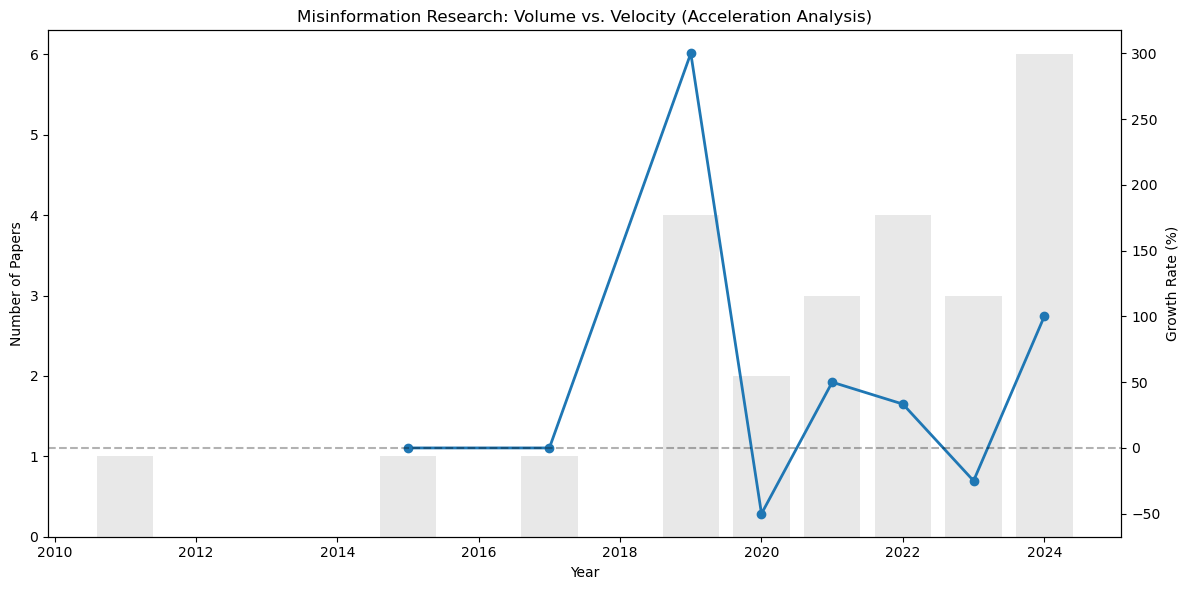

In [76]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Volume (Bar)
ax1.bar(yearly_counts['Year'], yearly_counts['Paper_Count'], color='lightgrey', alpha=0.5, label='Volume (Total Papers)')
ax1.set_ylabel('Number of Papers')
ax1.set_xlabel('Year')

# Plot Growth Rate (Line) - The Velocity
ax2 = ax1.twinx()
ax2.plot(yearly_counts['Year'], yearly_counts['YoY_Growth_Rate'], color='tab:blue', marker='o', linewidth=2, label='Velocity (YoY Growth %)')
ax2.set_ylabel('Growth Rate (%)')

# Add a horizontal line at 0 for growth
ax2.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.title('Misinformation Research: Volume vs. Velocity (Acceleration Analysis)')
fig.tight_layout()
plt.show()

In [77]:
#Methodology Shift

# 1. Define the Eras
early_era = df[df['Year'] <= 2020]['Abstract']
recent_era = df[df['Year'] >= 2021]['Abstract']

# 2. Re-use your keyword function (from Step 4)
early_keywords = get_clean_keywords(early_era, top_n=10)
recent_keywords = get_clean_keywords(recent_era, top_n=10)

print("--- Early Era Keywords (2015-2020) ---")
for word, count in early_keywords:
    print(f"{word:15} | {count}")

print("\n--- Recent Era Keywords (2021-2024) ---")
for word, count in recent_keywords:
    print(f"{word:15} | {count}")

--- Early Era Keywords (2015-2020) ---
corrective      | 21
messages        | 17
misinformation  | 15
intention       | 13
industry        | 10
current         | 9
deception       | 9
strategies      | 8
media           | 8
tobacco         | 8

--- Recent Era Keywords (2021-2024) ---
misinformation  | 62
corrective      | 21
crisis          | 18
news            | 16
information     | 15
knowledge       | 14
communication   | 13
media           | 13
health          | 13
correction      | 13


In [78]:
# The Solution Trend : Check if solutions evolve between eras

solution_list = ['debunking', 'prebunking', 'inoculation', 'fact', 'labeling', 'nudging', 'warning']

def count_specific_solutions(text_series):
    text = " ".join(text_series.astype(str)).lower()
    return {word: text.count(word) for word in solution_list}

early_solutions = count_specific_solutions(early_era)
recent_solutions = count_specific_solutions(recent_era)

print("Early Solutions:", early_solutions)
print("Recent Solutions:", recent_solutions)

Early Solutions: {'debunking': 0, 'prebunking': 0, 'inoculation': 3, 'fact': 3, 'labeling': 0, 'nudging': 0, 'warning': 0}
Recent Solutions: {'debunking': 13, 'prebunking': 2, 'inoculation': 1, 'fact': 10, 'labeling': 0, 'nudging': 0, 'warning': 2}


In [79]:
#Broad Disciplines Shift 

# 1. Function to get top disciplines for a specific era
def get_top_disciplines(df_subset, top_n=5):
    # Explode the disciplines (handling the cleaning we did earlier)
    exploded = df_subset['Broad_Disciplines'].str.split(';').explode().str.strip()
    # Filter out empty strings
    exploded = exploded[exploded != ""]
    return exploded.value_counts(normalize=True).head(top_n) * 100

# 2. Compare the Eras
early_dominance = get_top_disciplines(df[df['Year'] <= 2020])
recent_dominance = get_top_disciplines(df[df['Year'] >= 2021])

print("--- Early Era Disciplinary Dominance (2015-2020) ---")
print(early_dominance)

print("\n--- Recent Era Disciplinary Dominance (2021-2024) ---")
print(recent_dominance)

--- Early Era Disciplinary Dominance (2015-2020) ---
Broad_Disciplines
computer science     24.137931
psychology           20.689655
medicine             13.793103
political science    13.793103
business              6.896552
Name: proportion, dtype: float64

--- Recent Era Disciplinary Dominance (2021-2024) ---
Broad_Disciplines
psychology           23.636364
computer science     21.818182
political science    18.181818
business              7.272727
philosophy            7.272727
Name: proportion, dtype: float64


# SMALL-SCALE EMBEDDING ANALYSIS

In [80]:
# Vectorizing the Abstracts

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Initialize the Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)

# 2. Create the Embeddings (Sparse Matrix)

tfidf_matrix = vectorizer.fit_transform(df['Abstract'].astype(str))

print(f"Matrix Shape: {tfidf_matrix.shape}") 

Matrix Shape: (25, 500)


In [81]:
# Measuring Semantic Similarity 

# Observe two papers that are the "most similar" in the dataset based on their abstract content, not just keywords

# Calculate Cosine Similarity between all papers
dist_matrix = cosine_similarity(tfidf_matrix)

# Find the most similar pair (excluding the diagonal which is 1.0)
np.fill_diagonal(dist_matrix, 0)
index = np.unravel_index(np.argmax(dist_matrix, axis=None), dist_matrix.shape)

print(f"Most Similar Papers found at indices: {index}")
print(f"Paper A: {df.iloc[index[0]]['Title']}")
print(f"Paper B: {df.iloc[index[1]]['Title']}")
print(f"Similarity Score: {dist_matrix[index]:.4f}")

Most Similar Papers found at indices: (1, 11)
Paper A: Crisis Misinformation and Corrective Strategies in Social-Mediated Crisis Communication
Paper B: Debunking misinformation in times of crisis: Exploring misinformation correction strategies for effective internal crisis communication
Similarity Score: 0.5881


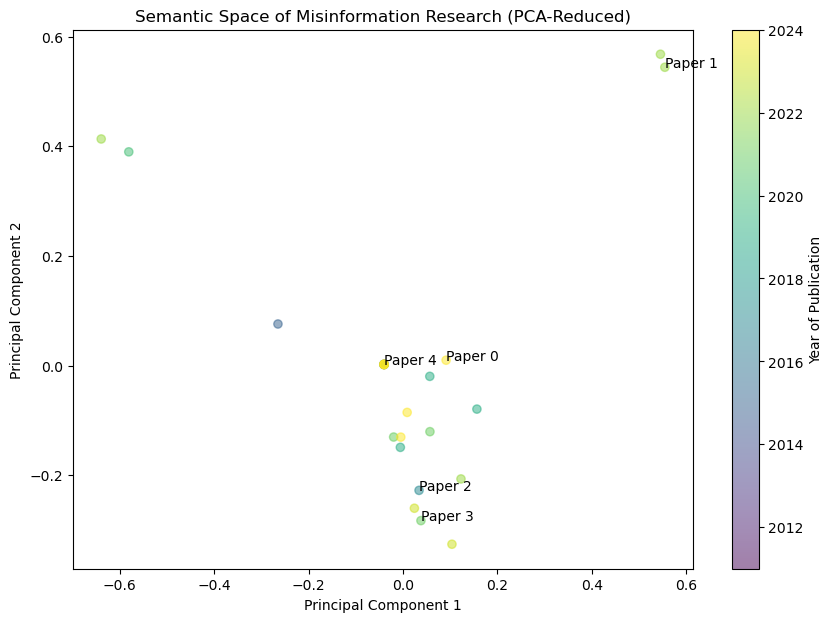

In [82]:
# Dimensionality Reduction 
# Since a 500-dimension matrix is impossible to "see", PCA is used to squash it into 2D for a scatter plot

from sklearn.decomposition import PCA

# Reduce to 2 dimensions
pca = PCA(n_components=2)
coords = pca.fit_transform(tfidf_matrix.toarray())

# Plot the "Semantic Map" of your research
plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5, c=df['Year'], cmap='viridis')
plt.colorbar(label='Year of Publication')

# Label a few points for context
for i in range(5):
    plt.annotate(f"Paper {i}", (coords[i, 0], coords[i, 1]))

plt.title("Semantic Space of Misinformation Research (PCA-Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

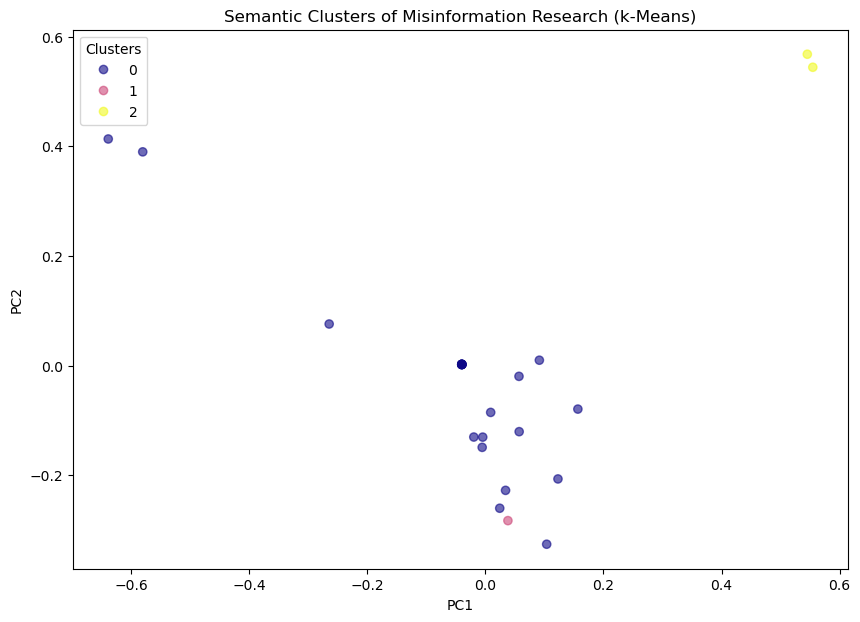

--- CLUSTER FLAVOR ANALYSIS ---

CLUSTER 0 (22 papers):
 - misinformation: 60
 - corrective: 37
 - messages: 21
 - news: 20
 - strategies: 18
 - fake: 18
 - media: 17
 - information: 16
 - correction: 15
 - intention: 13

CLUSTER 1 (1 papers):
 - covid: 3
 - health: 3
 - misperceptions: 3
 - misinformation: 2
 - social: 2
 - media: 2
 - coronavirus: 2
 - world: 2
 - organization: 2
 - shareable: 2

CLUSTER 2 (2 papers):
 - crisis: 18
 - misinformation: 15
 - communication: 12
 - social: 4
 - corrective: 4
 - internal: 4
 - outcomes: 3
 - key: 3
 - effective: 3
 - employees: 3


In [83]:
#Clustering

from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# 1. Perform k-Means Clustering (Week 2 & 3 concept)
# We'll use 3 clusters to see if the data splits into clear "flavors"
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(tfidf_matrix)

# 2. Visualize the Clusters using your PCA coordinates
plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df['Cluster'], cmap='plasma', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("Semantic Clusters of Misinformation Research (k-Means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 3. Analyze the "Flavor" of each Cluster
# We'll re-use a simplified version of your keyword function
from collections import Counter
import re

def get_cluster_keywords(text_list, stop_words, top_n=10):
    all_text = " ".join(text_list.astype(str)).lower()
    words = re.findall(r'\b[a-z]{3,}\b', all_text)
    # Using the stop_words set we defined earlier
    meaningful_words = [w for w in words if w not in stop_words]
    return Counter(meaningful_words).most_common(top_n)

print("--- CLUSTER FLAVOR ANALYSIS ---")
for i in range(num_clusters):
    cluster_docs = df[df['Cluster'] == i]['Abstract']
    keywords = get_cluster_keywords(cluster_docs, stop_words)
    
    print(f"\nCLUSTER {i} ({len(cluster_docs)} papers):")
    for word, count in keywords:
        print(f" - {word}: {count}")